In [2]:
!mamba install pandas numpy matplotlib scikit-learn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.807 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.7.22  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.5.1      pyhd8ed1ab_0         conda-forge
+ idna                3.19       pyhcf101f3_0         conda-forge
+ joblib              1.5.3      py313h1804a44_3      emscripten-forge-4x
+ narwhals            2.25.0     pyhcf101f3_0         conda-forge
+ pandas              3.0.5      np23py313h1e705a5_0  emscripten-forge-4x
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ python-tzdata       2026.3     pyhd8ed1ab_0         conda-forge
+ requests          

In [3]:
import pandas as pd

df = pd.read_csv('Clean_Dataset.csv')

In [4]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [5]:
df.airline.value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

In [6]:
df.source_city.value_counts()

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

In [7]:
df.destination_city.value_counts()

destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64

In [8]:
df.departure_time.value_counts()

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

In [9]:
df.arrival_time.value_counts()

arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64

In [10]:
df.stops.value_counts()

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

In [11]:
df['class'].value_counts()

class
Economy     206666
Business     93487
Name: count, dtype: int64

In [12]:
df['duration'].min()

np.float64(0.83)

In [13]:
df['duration'].max()

np.float64(49.83)

In [14]:
df['duration'].median()

np.float64(11.25)

## Preprocessing

In [15]:
df = df.drop('Unnamed: 0' , axis = 1)
df = df.drop('flight', axis = 1)

df['class'] = df['class'].apply(lambda x : 1 if x == 'Business' else 0) 

In [16]:
df.stops = pd.factorize(df.stops)[0]

In [17]:
df

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,0,Night,Mumbai,0,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,0,Morning,Mumbai,0,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,0,Early_Morning,Mumbai,0,2.17,1,5956
3,Vistara,Delhi,Morning,0,Afternoon,Mumbai,0,2.25,1,5955
4,Vistara,Delhi,Morning,0,Morning,Mumbai,0,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,1,Evening,Hyderabad,1,10.08,49,69265
300149,Vistara,Chennai,Afternoon,1,Night,Hyderabad,1,10.42,49,77105
300150,Vistara,Chennai,Early_Morning,1,Night,Hyderabad,1,13.83,49,79099
300151,Vistara,Chennai,Early_Morning,1,Evening,Hyderabad,1,10.00,49,81585


In [18]:
df = df.join(pd.get_dummies(df.airline, prefix='airline', dtype=int)).drop('airline', axis =1)
df = df.join(pd.get_dummies(df.source_city, prefix='source', dtype=int)).drop('source_city', axis =1)
df = df.join(pd.get_dummies(df.destination_city, prefix='dest', dtype=int)).drop('destination_city', axis =1)
df = df.join(pd.get_dummies(df.arrival_time, prefix='arrival', dtype=int)).drop('arrival_time', axis =1)
df = df.join(pd.get_dummies(df.departure_time, prefix='departure', dtype=int)).drop('departure_time', axis =1)

In [19]:
df

,stops,class,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,arrival_Evening,arrival_Late_Night,arrival_Morning,arrival_Night,departure_Afternoon,departure_Early_Morning,departure_Evening,departure_Late_Night,departure_Morning,departure_Night
0,0,0,2.17,1,5953,0,0,0,0,1,...,0,0,0,1,0,0,1,0,0,0
1,0,0,2.33,1,5953,0,0,0,0,1,...,0,0,1,0,0,1,0,0,0,0
2,0,0,2.17,1,5956,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0,2.25,1,5955,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,2.33,1,5955,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,1,10.08,49,69265,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
300149,1,1,10.42,49,77105,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
300150,1,1,13.83,49,79099,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
300151,1,1,10.00,49,81585,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0


## Training Regression Model

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

x,y = df.drop('price', axis =1 ), df.price

In [21]:

x_train, x_test , y_train, y_test = train_test_split(x,y, test_size = 0.2)

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# 1. Shrink the grid so it finishes today
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'] 
}

reg = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(estimator=reg, param_grid=param_grid, cv=2, verbose=1)


x_train_sample = x_train[:5000]
y_train_sample = y_train[:5000]

grid_search.fit(x_train_sample, y_train_sample)

print("Best Parameters:", grid_search.best_params_)

Fitting 2 folds for each of 16 candidates, totalling 32 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [27]:
# Extract the single best model from the grid search
best_reg = grid_search.best_estimator_

# Now score the best model
best_reg.score(x_train_sample, y_train_sample)

0.9923923199251696

In [28]:
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

y_pred = best_reg.predict(x_test)

print('R2: ', r2_score(y_test, y_pred))
print('MAE: ', mean_absolute_error(y_test, y_pred))  
print('MSE: ', mean_squared_error(y_test, y_pred))  
print('RMSE: ', math.sqrt(mean_squared_error(y_test, y_pred))) 

R2:  0.9536929070413094
MAE:  3044.907521057545
MSE:  24113136.209016934
RMSE:  4910.512825460996


Text(0.5, 1.0, 'Prediction VS Actual Price')

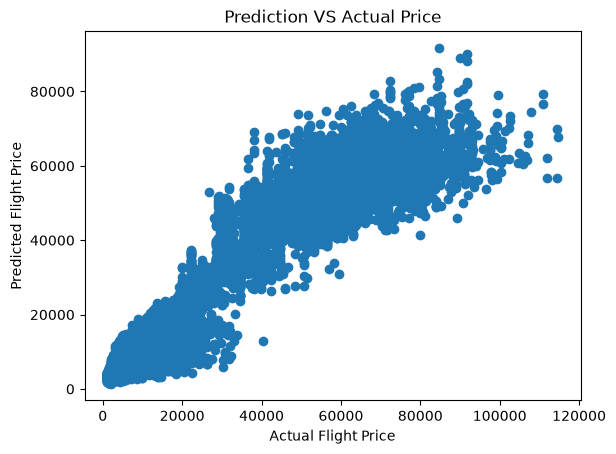

In [29]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel('Actual Flight Price') 
plt.ylabel('Predicted Flight Price')  
plt.title('Prediction VS Actual Price')

In [30]:
df.price.describe()

count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64

In [33]:
importances = dict(zip(best_reg.feature_names_in_, best_reg.feature_importances_))
sorted_importances = sorted(importances.items(), key = lambda x: x[1], reverse = True)

sorted_importances


[('class', np.float64(0.6989793623934338)),
 ('duration', np.float64(0.05302167043269075)),
 ('airline_Vistara', np.float64(0.052825655782889294)),
 ('days_left', np.float64(0.0392874535538135)),
 ('airline_Indigo', np.float64(0.02184863100137695)),
 ('stops', np.float64(0.019890207593871948)),
 ('airline_Air_India', np.float64(0.015649502952222758)),
 ('airline_GO_FIRST', np.float64(0.012563070276587972)),
 ('airline_AirAsia', np.float64(0.008877001199661052)),
 ('dest_Mumbai', np.float64(0.004565918991561517)),
 ('source_Delhi', np.float64(0.0038735286522211232)),
 ('dest_Kolkata', np.float64(0.0036948717507457843)),
 ('arrival_Night', np.float64(0.0036879909533948747)),
 ('dest_Delhi', np.float64(0.0036824540879239584)),
 ('departure_Morning', np.float64(0.0036790359695720314)),
 ('source_Kolkata', np.float64(0.0036074758214251065)),
 ('dest_Bangalore', np.float64(0.0035464923652568695)),
 ('source_Hyderabad', np.float64(0.003421563711909677)),
 ('arrival_Evening', np.float64(0.0033

<BarContainer object of 10 artists>

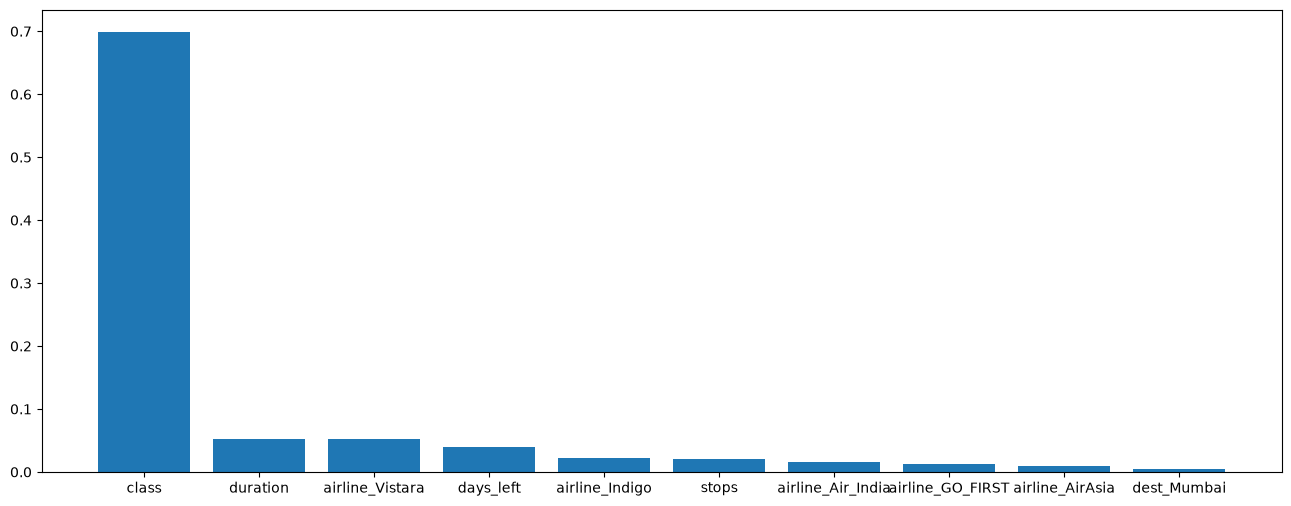

In [34]:
plt.figure(figsize=(16,6))
plt.bar([x[0]for x in sorted_importances[:10]],[x[1] for x in sorted_importances[:10]])

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# 1. Shrink the grid so it finishes today
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'] 
}

reg = RandomForestRegressor(random_state=42)

# 2. Lower cv to 2, and change verbose to 1 for clean output!
grid_search = GridSearchCV(estimator=reg, param_grid=param_grid, cv=2, verbose=1)

# 3. Slice the training data to just 5,000 rows
x_train_sample = x_train[:5000]
y_train_sample = y_train[:5000]

# 4. Fit using the training sample, NOT the test data!
grid_search.fit(x_train_sample, y_train_sample)

print("Best Parameters:", grid_search.best_params_)

Fitting 2 folds for each of 16 candidates, totalling 32 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [36]:
!mamba install scipy

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.475 seconds
All requested packages already installed.


In [41]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.ensemble import RandomForestRegressor

param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt'] 
}

# Removed n_jobs=-1 so it works in the browser
reg = RandomForestRegressor(random_state=42)

# Changed verbose=1 for clean output, removed n_jobs=-1
random_search = RandomizedSearchCV(estimator=reg, 
                                   param_distributions=param_dist, 
                                   n_iter=5, 
                                   cv=3, 
                                   scoring='neg_mean_squared_error', 
                                   verbose=1, 
                                   random_state=10)

# Slice the data to just 5,000 rows to prevent the browser from crashing
x_train_sample = x_train[:5000]
y_train_sample = y_train[:5000]

# Fit using the sampled data!
random_search.fit(x_train_sample, y_train_sample)
best_regressor = random_search.best_estimator_

print("Random Search Complete!")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Random Search Complete!


In [42]:
best_regressor.score(x_test, y_test)

0.951136565630014

In [43]:
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

y_pred = best_regressor.predict(x_test)

print('R2: ', r2_score(y_test, y_pred))
print('MAE: ', mean_absolute_error(y_test, y_pred))  
print('MSE: ', mean_squared_error(y_test, y_pred))  
print('RMSE: ', math.sqrt(mean_squared_error(y_test, y_pred))) 

R2:  0.951136565630014
MAE:  3221.2259004045286
MSE:  25444280.202493392
RMSE:  5044.232369993812


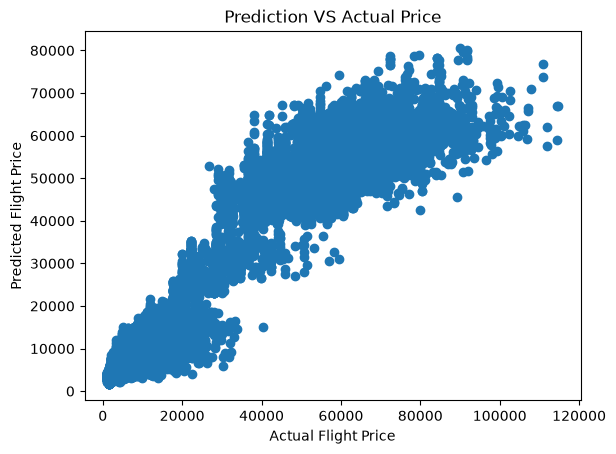

In [44]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel('Actual Flight Price')
plt.ylabel('Predicted Flight Price')
plt.title('Prediction VS Actual Price')
plt.show() # <--- Add this to hide the text output!